# Analisis Teen Mental Health - Kelompok 4

Notebook ini dibuat untuk menyelesaikan Post Test Praktikum Algoritma dan Pemrograman 2026 Kelas E - Teen Mental Health.

Library yang digunakan: `pandas`, `matplotlib`, dan `seaborn`.

Kategori yang dikerjakan:
1. Agregasi
2. Filter
3. Korelasi
4. Distribusi

In [18]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

OUTPUT_DIR = "kelompok4_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

## Load Dataset

Bagian ini membaca file CSV dan membersihkan kolom numerik agar bisa dihitung dengan benar.

In [19]:
df = pd.read_csv("Kelas E_Teen Mental Health.csv")

display(df.head())

print("Ukuran dataset:")
print(df.shape)

print("\nDaftar kolom:")
print(df.columns.tolist())

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


Ukuran dataset:
(1200, 13)

Daftar kolom:
['age', 'gender', 'daily_social_media_hours', 'platform_usage', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'social_interaction_level', 'stress_level', 'anxiety_level', 'addiction_level', 'depression_label']


## Kategori A

Hitung total jumlah sampel data remaja berdasarkan kombinasi variabel age dan gender. Tampilkan dalam Grouped Bar Chart

In [27]:
kategori_a = (
    df.groupby(["age", "gender"])
      .size()
      .reset_index(name="jumlah")
)

kategori_a

,age,gender,jumlah
0,13,female,93
1,13,male,107
2,14,female,78
3,14,male,75
4,15,female,89
5,15,male,91
6,16,female,77
7,16,male,86
8,17,female,97
9,17,male,73


VISUALISASI

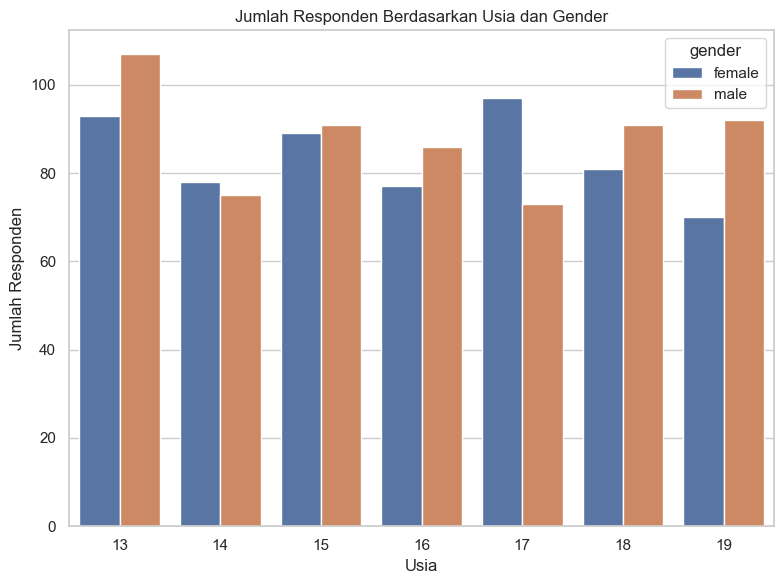


Distribusi jumlah responden laki-laki dan perempuan
relatif merata pada setiap kelompok usia.



In [ ]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=kategori_a,
    x="age",
    y="jumlah",
    hue="gender"
)

plt.title("Jumlah Responden Berdasarkan Usia dan Gender")
plt.xlabel("Usia")
plt.ylabel("Jumlah Responden")

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/grafik_kategori_A.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("""
Distribusi jumlah responden laki-laki dan perempuan
relatif merata pada setiap kelompok usia.
""")

## Kategori B

Cari remaja pengguna TikTok yang memiliki tingkat stres di atas rata-rata dan bandingkan dengan pengguna Instagram.Cari remaja pengguna aplikasi 'TikTok' yang memiliki tingkat stres (stress_level) di atas nilai median pengguna 'Instagram'. Tampilkan dalam Bar Chart

In [30]:
rata_stress = df["stress_level"].mean()

kategori_b = df[
    (df["platform_usage"].isin(["TikTok", "Instagram"])) &
    (df["stress_level"] > rata_stress)
]

platform_stress = (
    kategori_b["platform_usage"]
    .value_counts()
    .reset_index()
)

platform_stress.columns = [
    "platform_usage",
    "jumlah"
]

platform_stress

,platform_usage,jumlah
0,Instagram,202
1,TikTok,183


VISUALISASI

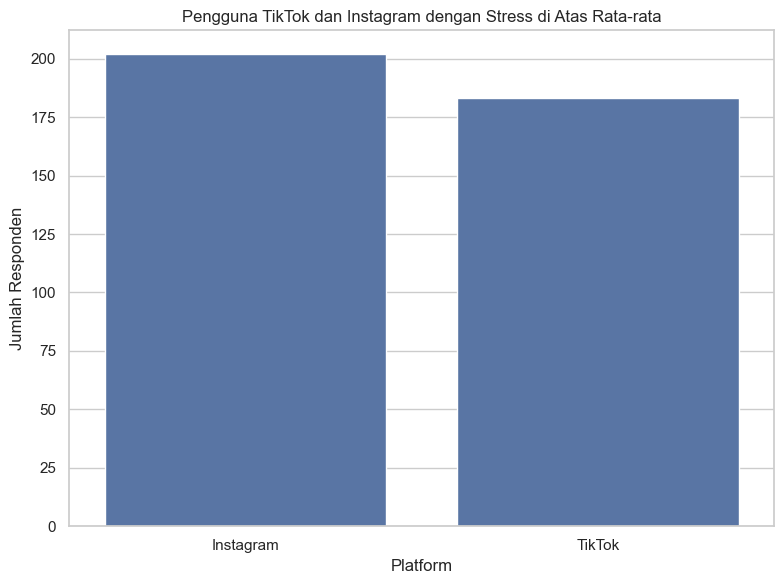


Grafik menunjukkan jumlah pengguna TikTok dan Instagram
yang memiliki tingkat stres di atas rata-rata.



In [32]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=platform_stress,
    x="platform_usage",
    y="jumlah"
)

plt.title("Pengguna TikTok dan Instagram dengan Stress di Atas Rata-rata")
plt.xlabel("Platform")
plt.ylabel("Jumlah Responden")

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/grafik_kategori_B.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("""
Grafik menunjukkan jumlah pengguna TikTok dan Instagram
yang memiliki tingkat stres di atas rata-rata.
""")

## Kategori C

Bandingkan hubungan korelasi antara durasi layar sebelum tidur (screen_time_before_sleep) dengan tingkat stres (stress_level). Tampilkan dalam Scatter Plot

In [42]:
korelasi = df["screen_time_before_sleep"].corr(
    df["stress_level"]
)

print("Nilai Korelasi =", round(korelasi,4))

print("""
Nilai korelasi mendekati nol sehingga hubungan antara
screen time sebelum tidur dan tingkat stres pada dataset
ini sangat lemah atau hampir tidak ada.
""")

Nilai Korelasi = -0.0086

Nilai korelasi mendekati nol sehingga hubungan antara
screen time sebelum tidur dan tingkat stres pada dataset
ini sangat lemah atau hampir tidak ada.



VISUALISASI

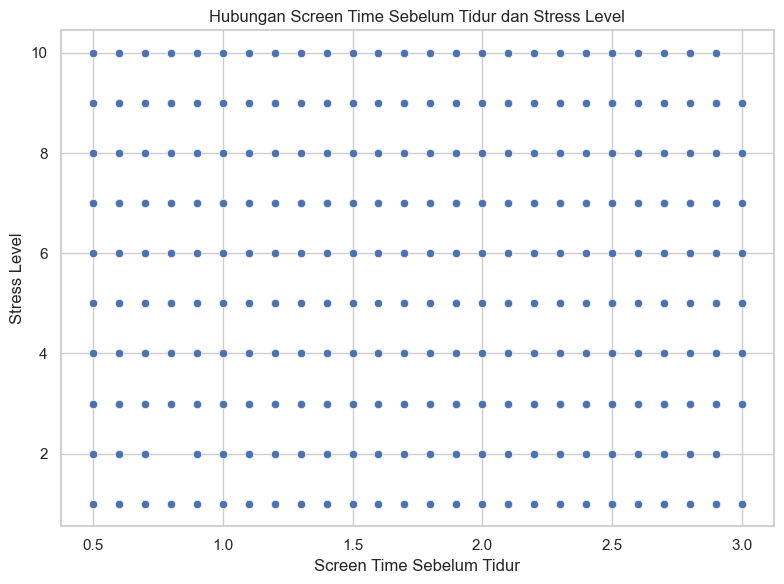

In [38]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="screen_time_before_sleep",
    y="stress_level"
)

plt.title("Hubungan Screen Time Sebelum Tidur dan Stress Level")
plt.xlabel("Screen Time Sebelum Tidur")
plt.ylabel("Stress Level")

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/grafik_kategori_C.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Kategori D

Tampilkan visualisasi bentuk sebaran distribusi variabel durasi tidur harian (sleep_hours) menggunakan Histogram + KDE

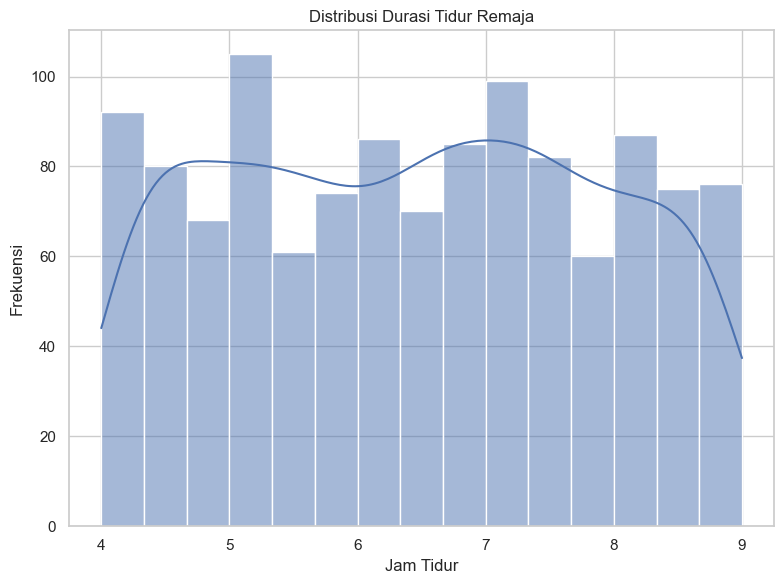


Distribusi durasi tidur responden tersebar pada rentang
sekitar 4 hingga 9 jam dan tidak menunjukkan kemencengan
yang sangat kuat ke salah satu sisi.



In [43]:
plt.figure(figsize=(8,6))

sns.histplot(
    data=df,
    x="sleep_hours",
    kde=True,
    bins=15
)

plt.title("Distribusi Durasi Tidur Remaja")
plt.xlabel("Jam Tidur")
plt.ylabel("Frekuensi")

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/grafik_kategori_D.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("""
Distribusi durasi tidur responden tersebar pada rentang
sekitar 4 hingga 9 jam dan tidak menunjukkan kemencengan
yang sangat kuat ke salah satu sisi.
""")

## OUTPUT WAJIB: Grafik 5 (Gabungan)

Menggabungkan seluruh visualisasi Kategori A, B, C, dan D dalam satu layout grid 2x2 menggunakan pendekatan objek `ax=axes[x, y]` tanpa menulis ulang logika datanya (memanggil ulang variabel yang sudah dihitung).

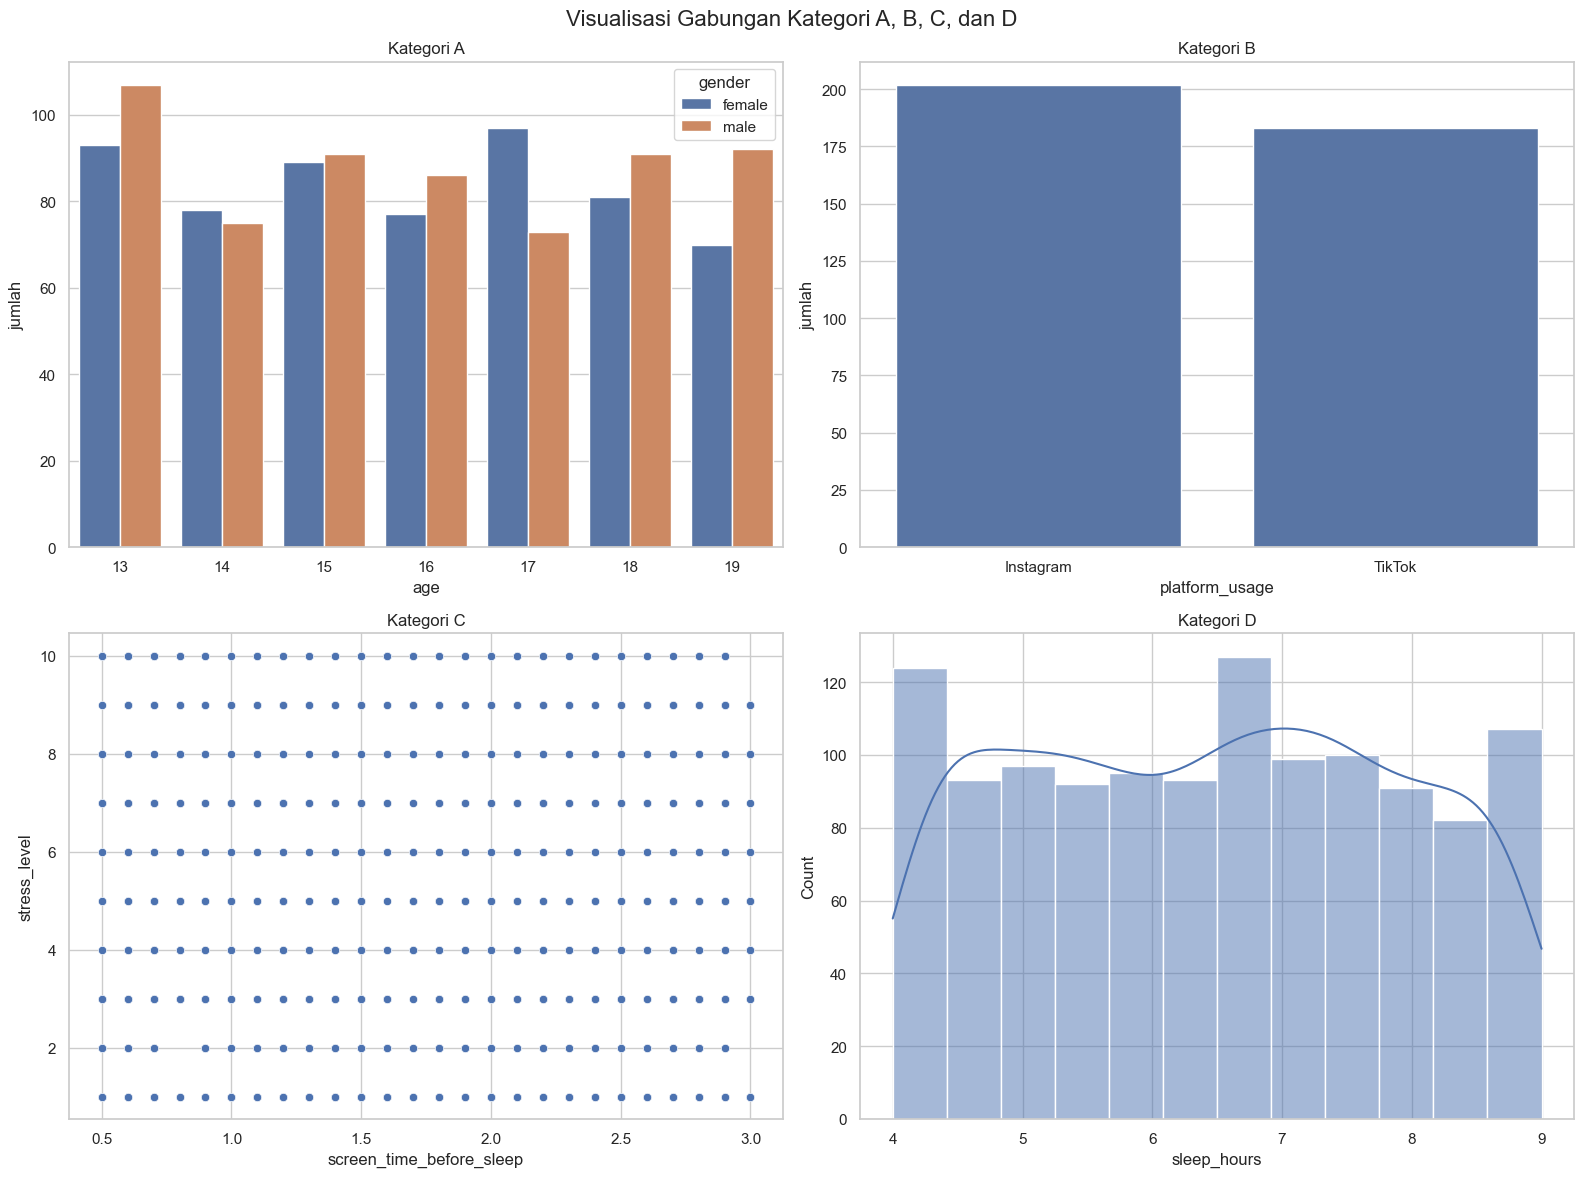

In [45]:
fig, axes = plt.subplots(
    2,2,
    figsize=(16,12)
)

sns.barplot(
    data=kategori_a,
    x="age",
    y="jumlah",
    hue="gender",
    ax=axes[0,0]
)

sns.barplot(
    data=platform_stress,
    x="platform_usage",
    y="jumlah",
    ax=axes[0,1]
)

sns.scatterplot(
    data=df,
    x="screen_time_before_sleep",
    y="stress_level",
    ax=axes[1,0]
)

sns.histplot(
    data=df,
    x="sleep_hours",
    kde=True,
    ax=axes[1,1]
)

fig.suptitle(
    "Visualisasi Gabungan Kategori A, B, C, dan D",
    fontsize=16
)

plt.tight_layout(rect=[0,0,1,0.97])

axes[0,0].set_title("Kategori A")
axes[0,1].set_title("Kategori B")
axes[1,0].set_title("Kategori C")
axes[1,1].set_title("Kategori D")

plt.tight_layout()
plt.show()